### Our question: Determine which criteria were the driving force behind survival and how does it rank in order ?

Goals for this Notebook:

1. import the data. 

2. first look into the data.

3. handle missing values 

4. transform data 

5. feature engineering 

6. Univartine analysis and bivarinate analysis  

7. results 

#### import the Data 
Data was collected from Kaggle with the following URL: https://www.kaggle.com/competitions/titanic/data

In [994]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



##### load the data 

In [995]:
df=pd.read_csv('train.csv')

#### first look 

In [996]:

df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [997]:
df.shape

(891, 12)

In [998]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [999]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [1000]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [1001]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [1002]:
new_df=['Pclass','Sex', 'SibSp',
       'Parch', 'Embarked']

In [1003]:
for i in new_df:
    print(df[f'{i}'].value_counts())


Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Sex
male      577
female    314
Name: count, dtype: int64
SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64
Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


#### missing Values handling 

we can see there are missing values in our data so we need detailed list and count of missing values 

In [1004]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

our first goal is to handle missing values in Age 

In [1005]:
df.Age.describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

Name columns consist of last name, title and final first name so we need to fix this and seperate this into multiple columns and focusing on title since it can help us in defining our missing values in our Age column 

In [1006]:
df['LastName'] = df['Name'].str.split(',').str[0]

In [1007]:
df['Title'] = df['Name'].str.split(',').str[1].str.split('.').str[0].str.strip()
df['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

We can see multiple variations of the same age group so we need to ensure a standardized list of title 

In [1008]:
title_map = {
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs',
    'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
    'Capt': 'Rare', 'Sir': 'Rare', 'Lady': 'Rare',
    'the Countess': 'Rare', 'Don': 'Rare', 'Jonkheer': 'Rare'
}

df['Title'] = df['Title'].replace(title_map)

df['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

Now we can check age median with the respect to age, status (Pclass) and Title 

In [1009]:
print(df.groupby('Sex')['Age'].median())
print()
print(df.groupby('Pclass')['Age'].median())
print()
print(df.groupby(['Pclass', 'Sex'])['Age'].median())
print()
print(df.groupby(['Pclass', 'Sex','Title'])['Age'].median())
print()

Sex
female    27.0
male      29.0
Name: Age, dtype: float64

Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

Pclass  Sex     Title 
1       female  Miss      30.0
                Mrs       40.0
                Rare      48.0
        male    Master     4.0
                Mr        40.0
                Rare      49.0
2       female  Miss      24.0
                Mrs       32.0
        male    Master     1.0
                Mr        31.0
                Rare      46.5
3       female  Miss      18.0
                Mrs       31.0
        male    Master     4.0
                Mr        26.0
Name: Age, dtype: float64



We have chosen to give our age more details and ensure that our filled age that into account Status, Sex and Title 

In [1010]:
df['Age'] = df.groupby(['Pclass', 'Sex','Title'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

df['Age'].isna().sum()

0

In [1011]:
df.Age.describe()

count    891.000000
mean      29.135993
std       13.491701
min        0.420000
25%       21.000000
50%       26.000000
75%       36.750000
max       80.000000
Name: Age, dtype: float64

We verfiy Our values after Filling Missing Values

In [1012]:
df.groupby('Title')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Title,,,,,,,,
Master,40.0,4.516750,3.433651,0.42,1.75,4.0,7.25,12.0
Miss,185.0,21.227027,11.658487,0.75,16.00,18.0,27.00,63.0
Mr,517.0,31.530948,11.529370,11.00,25.00,28.0,37.00,80.0
Mrs,126.0,35.714286,10.761306,14.00,28.25,35.0,42.00,63.0
Rare,23.0,45.695652,11.534276,23.00,39.00,49.0,53.00,70.0


In [1013]:
df['TicketCount'] = df.groupby('Ticket')['Ticket'].transform('count')

In [1014]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

so we can impute our cabin by checking the ticket with the following method: 
Last name is similair then we can take it as evidance as sharing the same cabin.
if they are have a sibling or Parent count there are chance they might be using the same cabin even if it is a different last name 
if it is not any of the following then it is Unkown 


In [1015]:
def impute_cabin(row):
    if pd.notna(row['Cabin']):
        return row['Cabin']
    
    # get ticket group
    ticket_group = df[df['Ticket'] == row['Ticket']]
    
    # same last name, has family, and has a known cabin
    match = ticket_group[
        (ticket_group['LastName'] == row['LastName']) &
        ((ticket_group['SibSp'] > 0) | (ticket_group['Parch'] > 0)) &
        (ticket_group['Cabin'].notna())
    ]
    
    if not match.empty:
        return match['Cabin'].iloc[0]
    
    return 'Unknown'

df['Cabin'] = df.apply(impute_cabin, axis=1)

# verify
df['Cabin'].value_counts()

Cabin
Unknown        685
C23 C25 C27      4
G6               4
B96 B98          4
F2               3
              ... 
C91              1
C32              1
E34              1
C54              1
C148             1
Name: count, Length: 148, dtype: int64

verify

In [1016]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,LastName,Title,TicketCount,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,Braund,Mr,1,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs,1,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,Heikkinen,Miss,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs,2,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,Allen,Mr,1,1


In [1017]:
df[df['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,LastName,Title,TicketCount,FamilySize
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,Icard,Miss,2,1
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,Stone,Mrs,2,1


In [1018]:
df[df['Ticket'].str.contains('113572')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,LastName,Title,TicketCount,FamilySize
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,Icard,Miss,2,1
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,Stone,Mrs,2,1


In [1019]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

We have filled Embarked with highest value count 

In [1020]:
df['Embarked'] = df['Embarked'].fillna('S')

In [1021]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     891 non-null    object 
 12  LastName     891 non-null    object 
 13  Title        891 non-null    object 
 14  TicketCount  891 non-null    int64  
 15  FamilySize   891 non-null    int64  
dtypes: float64(2), int64(7), object(7)
memory usage: 111.5+ KB


Now our missing Value have been handled and we can move on to analysis 

We drop the following columns since they are objects and wont be of help in nurmical data 

In [1022]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'LastName'])

In [1023]:
df['Cabin'] = df['Cabin'].str[0]

df['Cabin'].value_counts()

Cabin
U    685
C     60
B     47
D     33
E     32
A     15
F     14
G      4
T      1
Name: count, dtype: int64

In [1024]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Title,TicketCount,FamilySize
0,0,3,male,22.0,1,0,7.2500,U,S,Mr,1,2
1,1,1,female,38.0,1,0,71.2833,C,C,Mrs,1,2
2,1,3,female,26.0,0,0,7.9250,U,S,Miss,1,1
3,1,1,female,35.0,1,0,53.1000,C,S,Mrs,2,2
4,0,3,male,35.0,0,0,8.0500,U,S,Mr,1,1


We have changed our Sex column into a nurmical columns by changing male to 0 and female to 1 

In [1025]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

df['Sex'].value_counts()

Sex
0    577
1    314
Name: count, dtype: int64

We have chosen our numrical values to test and check correlation speically with our target 

In [1026]:
df_new=df[['Survived','Sex','Pclass', 'Age', 'Fare', 'TicketCount', 'FamilySize']]

In [1027]:
df_new.corr()

,Survived,Sex,Pclass,Age,Fare,TicketCount,FamilySize
Survived,1.000000,0.543351,-0.338481,-0.062785,0.257307,0.038247,0.016639
Sex,0.543351,1.000000,-0.131900,-0.103093,0.182333,0.154748,0.200988
Pclass,-0.338481,-0.131900,1.000000,-0.415261,-0.549500,-0.002633,0.065997
Age,-0.062785,-0.103093,-0.415261,1.000000,0.121194,-0.234736,-0.277296
Fare,0.257307,0.182333,-0.549500,0.121194,1.000000,0.345541,0.217138
TicketCount,0.038247,0.154748,-0.002633,-0.234736,0.345541,1.000000,0.748487
FamilySize,0.016639,0.200988,0.065997,-0.277296,0.217138,0.748487,1.000000


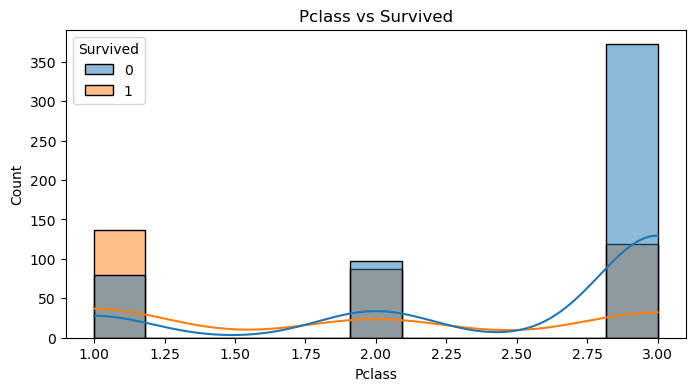

In [1028]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Pclass', hue='Survived', kde=True)
plt.title('Pclass vs Survived')
plt.show()

In [1029]:
df.groupby('Pclass')['Survived'].agg(['count', 'mean'])

,count,mean
Pclass,,
1,216,0.629630
2,184,0.472826
3,491,0.242363


Pclass vs Survived:
Class 3 has the lowest survival rate with 24%. Class 2 shows around 47% survival rate . Class 1 has 63% survival rate which is the best survival rate overall.

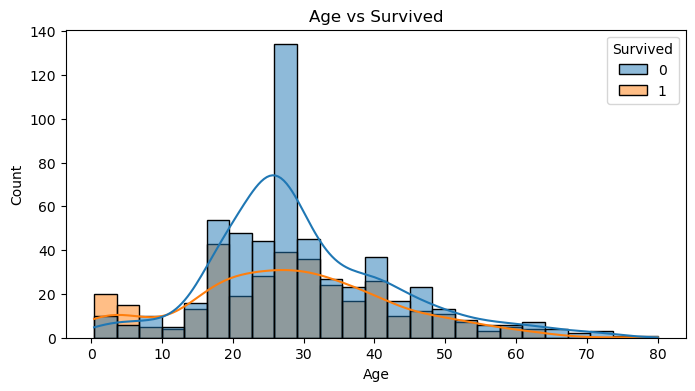

In [1030]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Age', hue='Survived', kde=True)
plt.title('Age vs Survived')
plt.show()

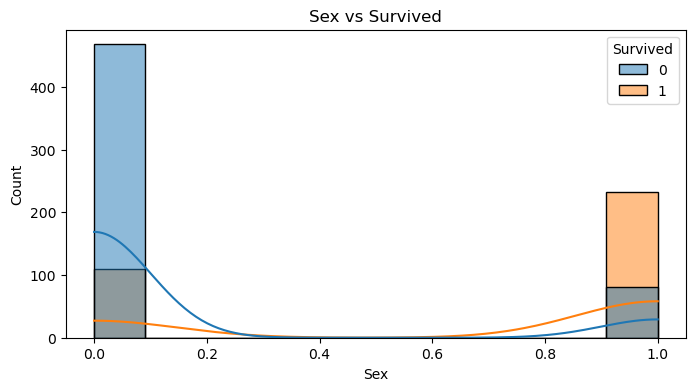

In [1031]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Sex', hue='Survived', kde=True)
plt.title('Sex vs Survived')
plt.show()

In [1032]:
df.groupby('Sex')['Survived'].agg(['count', 'mean'])

,count,mean
Sex,,
0,577,0.188908
1,314,0.742038


We can note that Females has overwhimaly higher survivial rate 

In [1033]:
df.pivot_table(index='Pclass', columns='Sex', values='Survived', aggfunc=['mean', 'count'])

mean           count     
Sex            0         1     0    1
Pclass                               
1       0.368852  0.968085   122   94
2       0.157407  0.921053   108   76
3       0.135447  0.500000   347  144

Female in First Class have over 96% survival rate, which decrease with stauts until 50% for Third Clas, the same pattern for male however it is decreases from 36% to 13.5% 

Here a much clearer Table 

In [1034]:
df.pivot_table(index='Pclass', columns='Sex', values='Survived',
               aggfunc=['mean', 'count'], margins=True)

mean                     count          
Sex            0         1       All     0    1  All
Pclass                                              
1       0.368852  0.968085  0.629630   122   94  216
2       0.157407  0.921053  0.472826   108   76  184
3       0.135447  0.500000  0.242363   347  144  491
All     0.188908  0.742038  0.383838   577  314  891

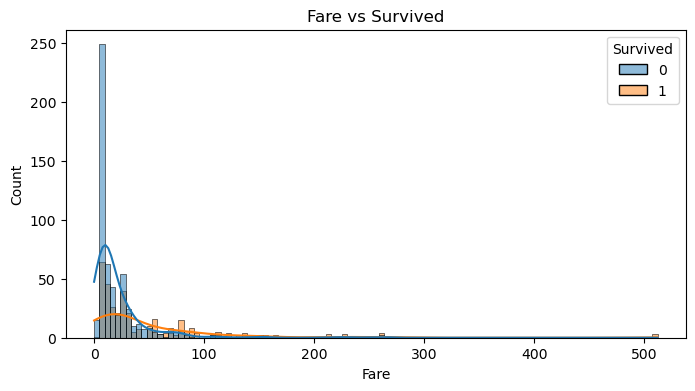

In [1035]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Fare', hue='Survived', kde=True)
plt.title('Fare vs Survived')
plt.show()

Fare vs Survived:
Passengers with fare over 50 tend to survive more. Below 50 survival drops significantly. Likely a proxy for Pclass rather than an independent signal.


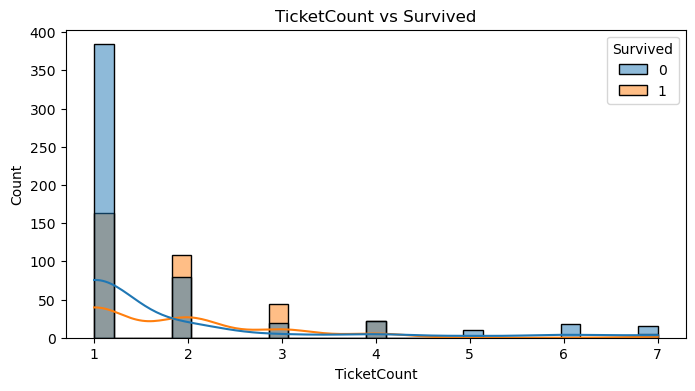

In [1036]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='TicketCount', hue='Survived', kde=True)
plt.title('TicketCount vs Survived')
plt.show()

TicketCount vs Survived:
Over 550 passengers traveled alone and only ~150 survived. Passengers in groups of 2-3 tickets had notably higher survival. Larger groups saw survival drop again.


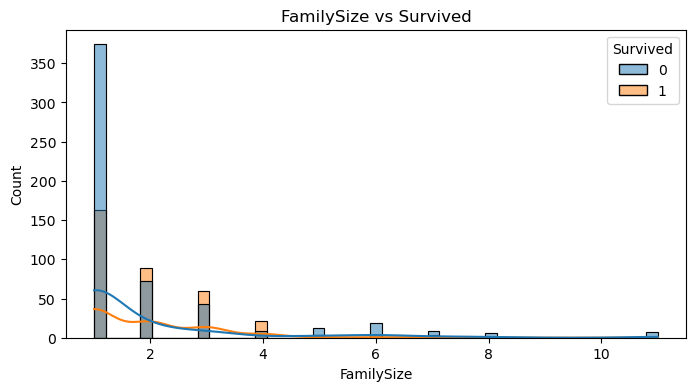

In [1037]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='FamilySize', hue='Survived', kde=True)
plt.title('FamilySize vs Survived')
plt.show()

FamilySize vs Survived:
Same pattern as TicketCount. Sweet spot is around 3-4 family members where survival peaks. Solo and large families both suffered.

#### ratio 

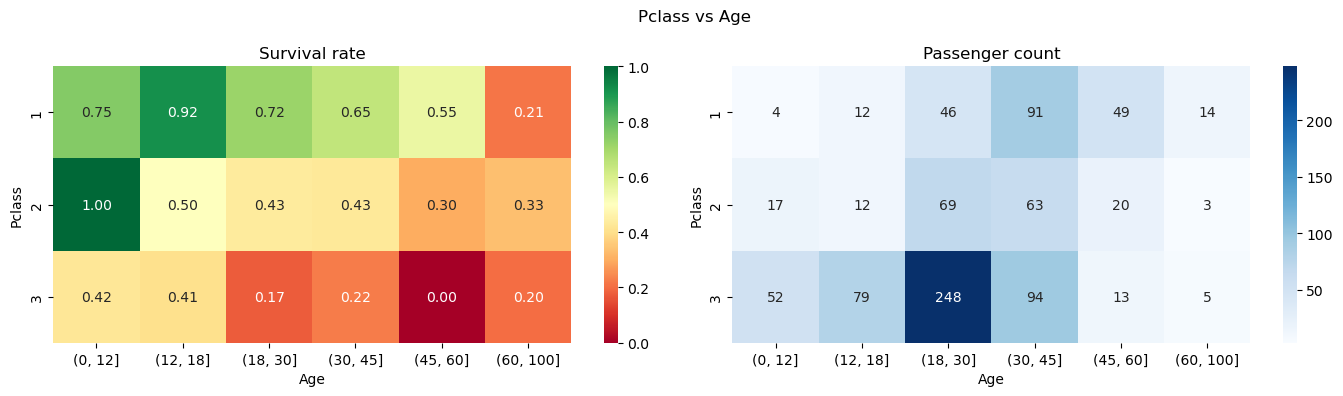

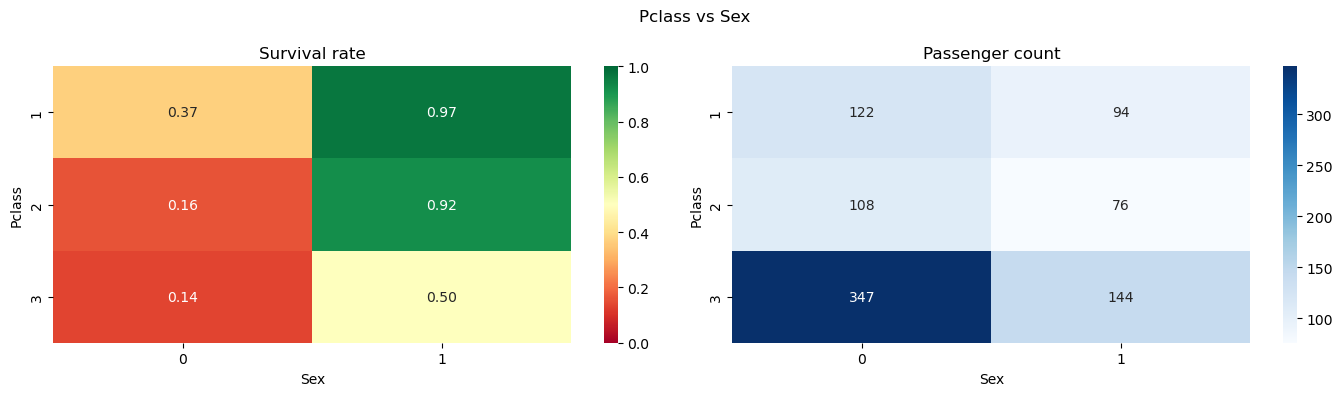

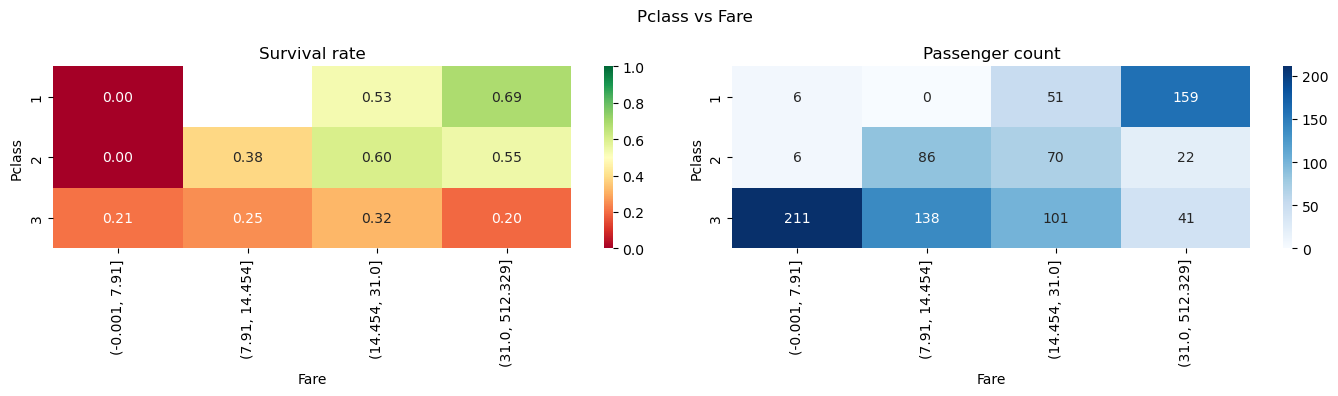

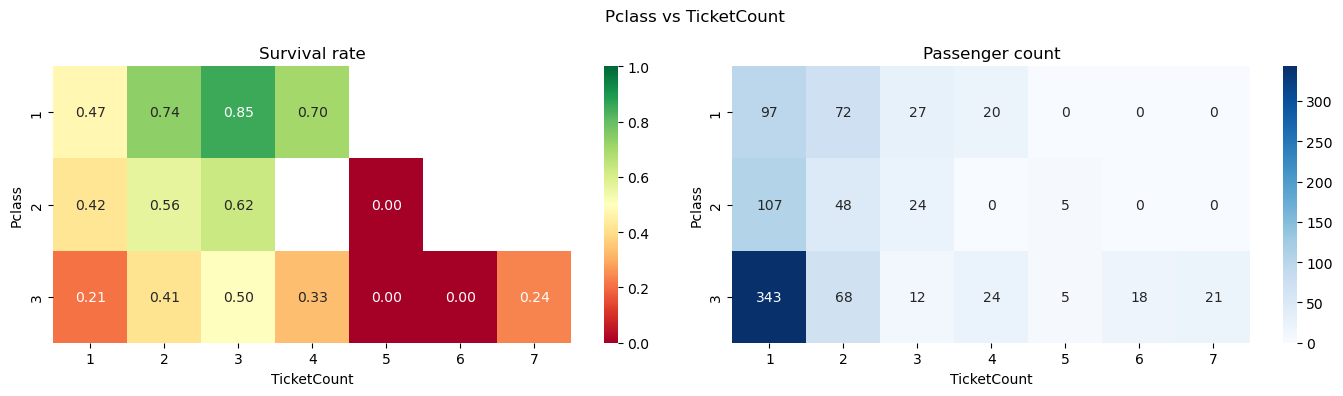

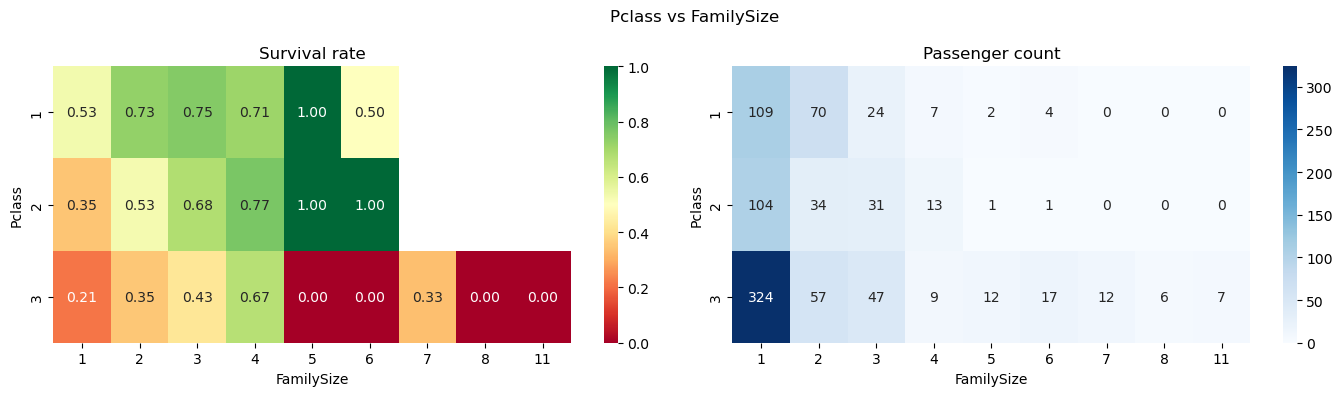

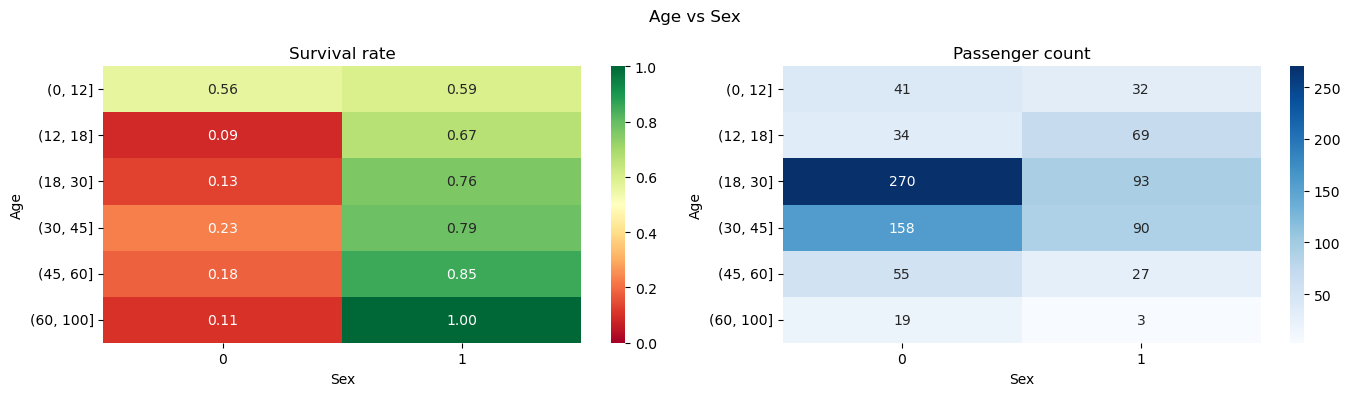

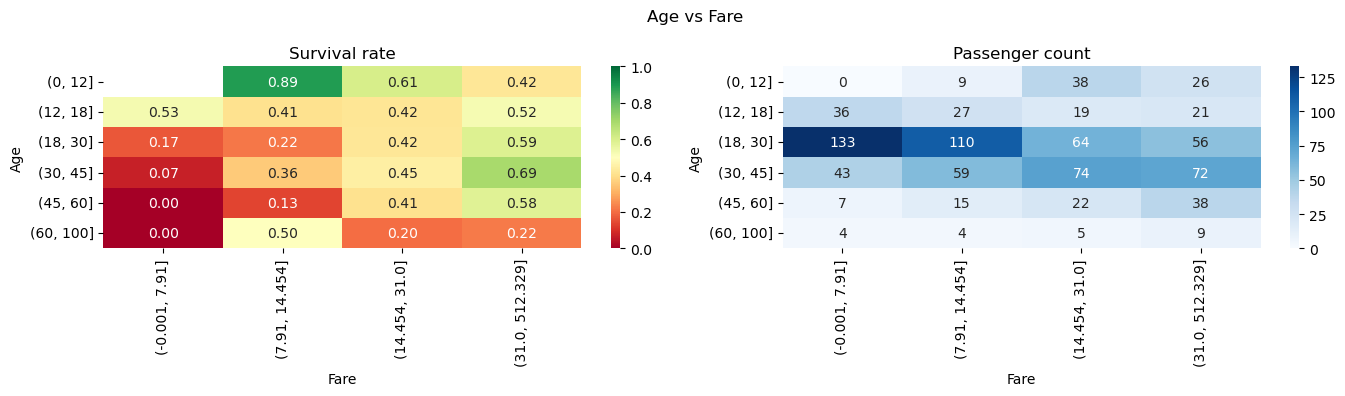

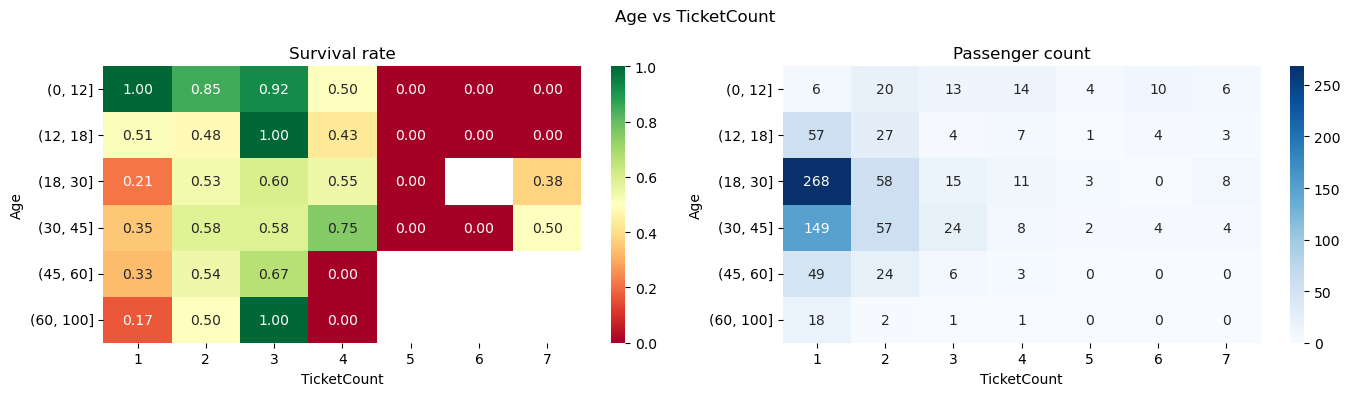

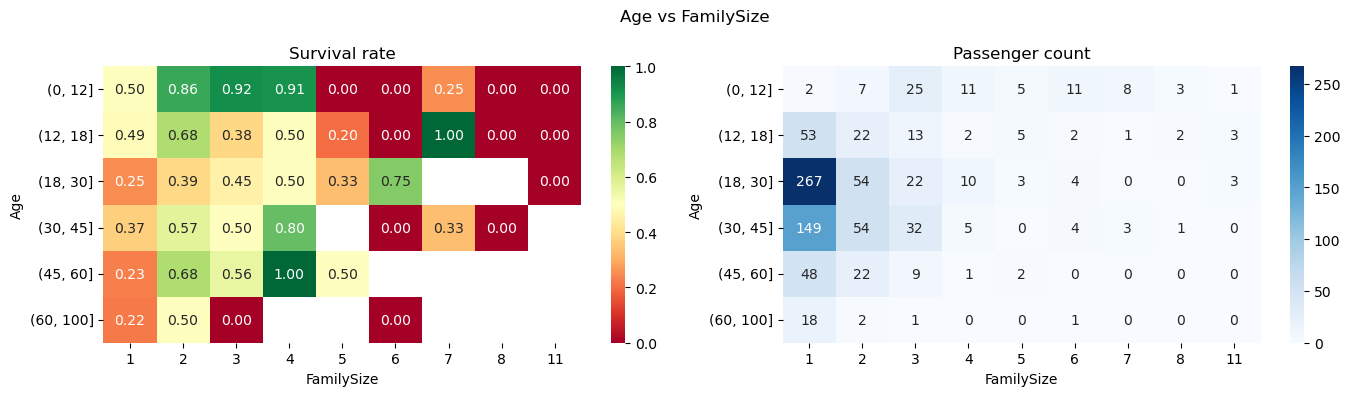

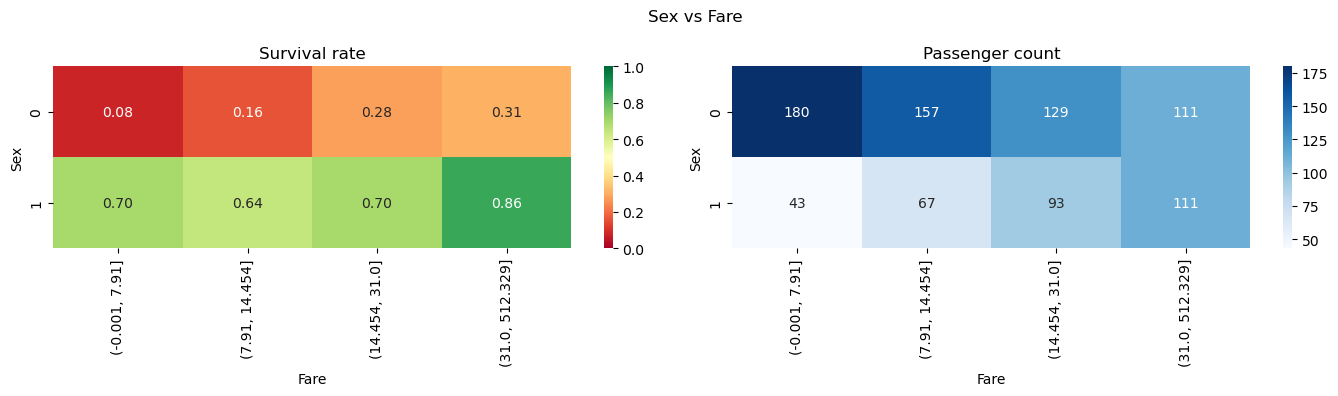

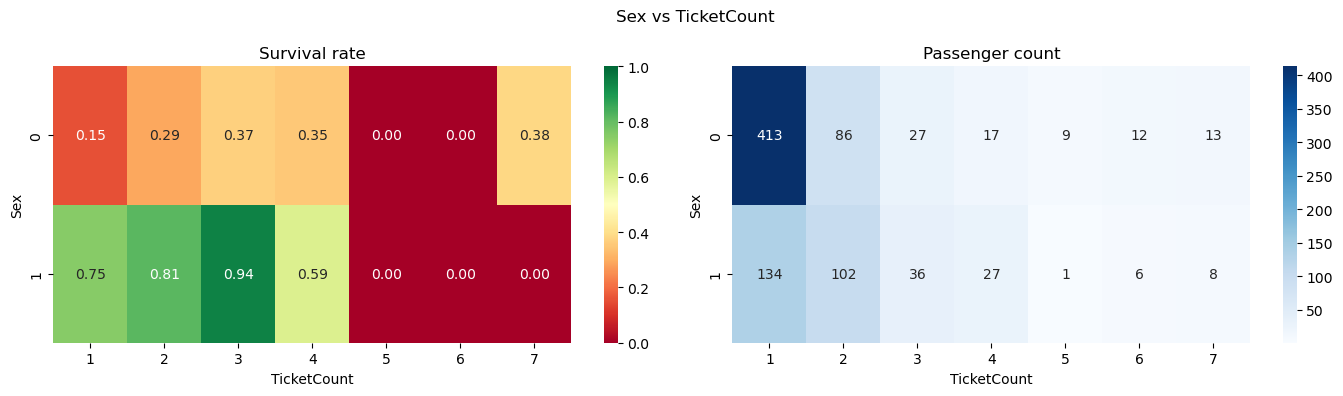

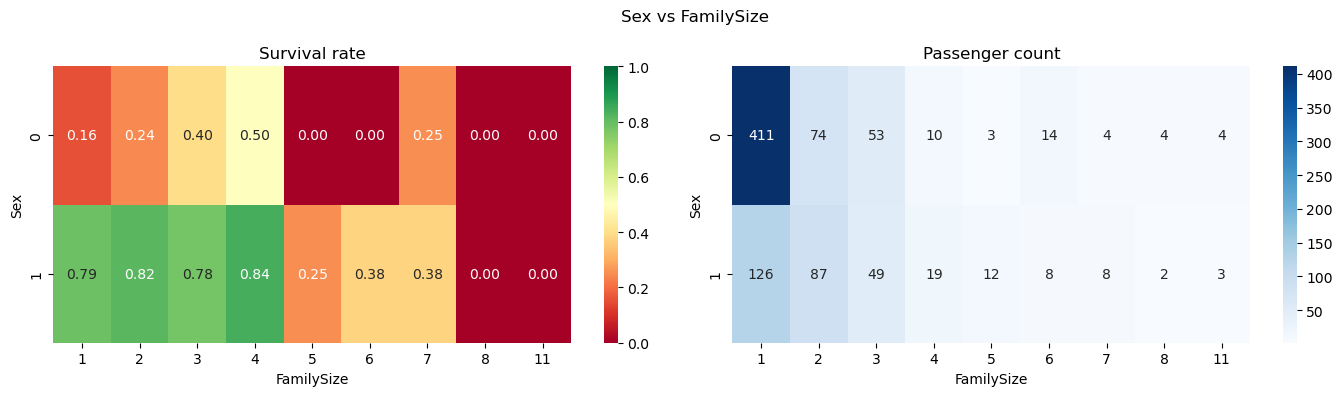

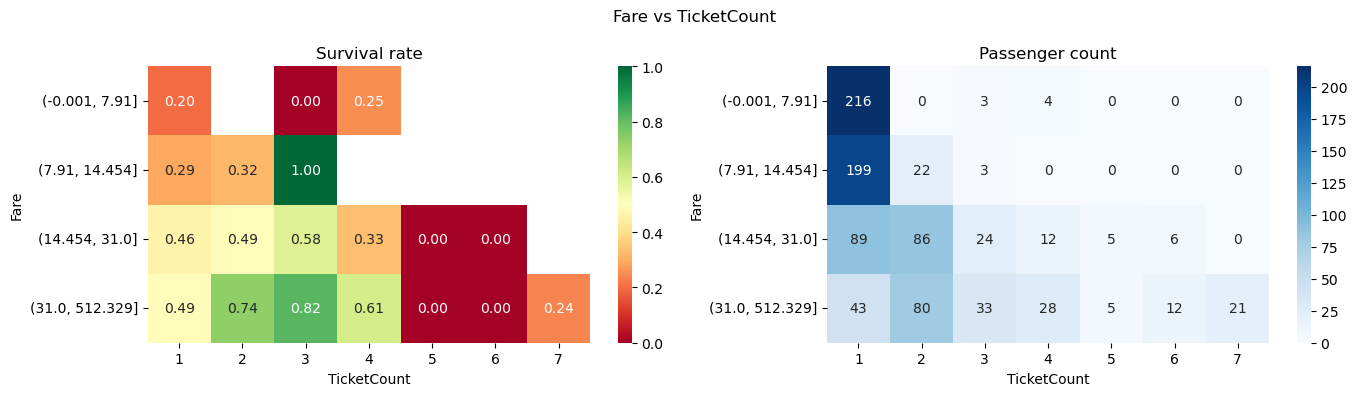

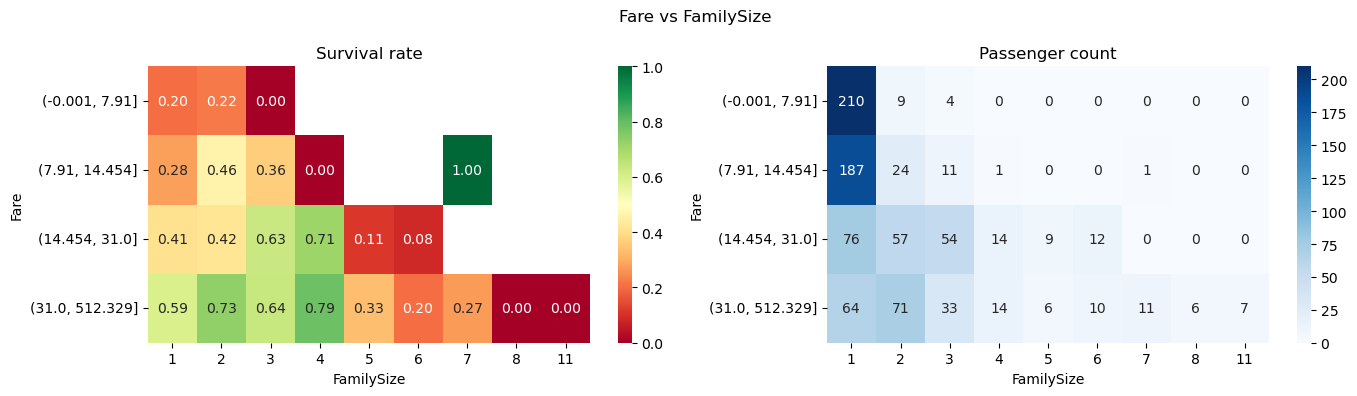

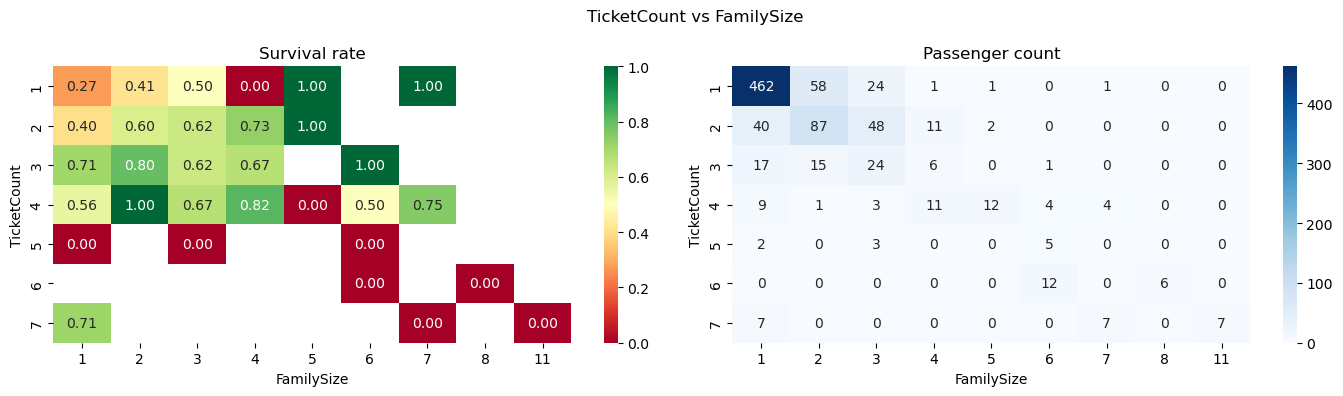

In [1038]:
import itertools
import pandas as pd

features = ['Pclass', 'Age', 'Sex', 'Fare', 'TicketCount', 'FamilySize']

plot_df = df.copy()
plot_df['Age']  = pd.cut(plot_df['Age'],  bins=[0, 12, 18, 30, 45, 60, 100])
plot_df['Fare'] = pd.qcut(plot_df['Fare'], q=4)

for feat1, feat2 in itertools.combinations(features, 2):
    rate  = pd.crosstab(plot_df[feat1], plot_df[feat2], values=plot_df['Survived'], aggfunc='mean')
    count = pd.crosstab(plot_df[feat1], plot_df[feat2])  # total passengers per cell

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    sns.heatmap(rate,  annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1, ax=ax1)
    sns.heatmap(count, annot=True, fmt='g',   cmap='Blues',                  ax=ax2)
    ax1.set_title('Survival rate')
    ax2.set_title('Passenger count')
    fig.suptitle(f'{feat1} vs {feat2}')
    plt.tight_layout()
    plt.show()

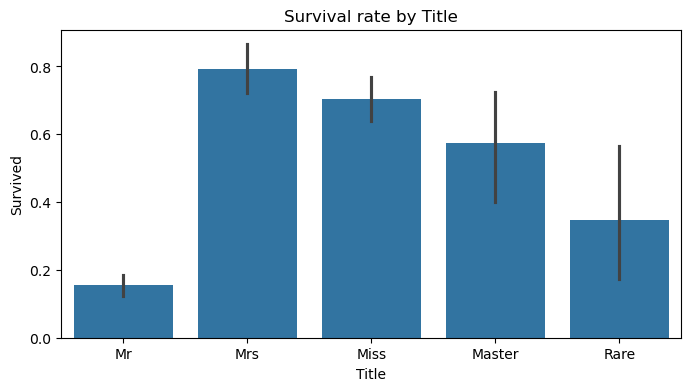

In [1039]:
# Survival rate by Title
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='Title', y='Survived')
plt.title('Survival rate by Title')
plt.show()


In [1040]:
df.pivot_table(index='Title', values='Survived',
               aggfunc=['mean', 'count'], margins=True)

,mean,count
,Survived,Survived
Title,,
Master,0.575000,40
Miss,0.702703,185
Mr,0.156673,517
Mrs,0.793651,126
Rare,0.347826,23
All,0.383838,891


##### Results 

for our ranking: 

1. Sex 

2. Class 

3. Age

4. Family Size 

here are our observations refer to heat map above for complete Picture: 

1. Passengers with Class 1 and from age 0 to 45 have a higher survival rate compared to their peers 

2. Passengers with Class 1 and Females have a higher survival rate compared to their male counterpart 

3. Passengers with Class 1 or 2 and fare that above $14.5 have a higher survival rate 

4. Passengers with Class 1 or 2 and fare that are in a group from 2-4 have a higher survival rate 

5. Passengers with Class 2 and a family ranging from 2-6 have higher survival rate, while Class 3 and family of 4 has a higher survival rate 

6. Survival of females increase as their fare increase, while male with 0-12 have a higher survival  rate compared to the rest of the males 

7. Children 0-12 survival chances decreases as their fare increases, while people with higher fares survival peaks at 30-45 

8. ticket bought in a group of 5 and higher have less survival chances, while group of 2-3 of a bought tickets have a higher survival chances 

9. the female survival increase above around $7 and peaks at the highest, while male increase proportional to their fare 

10. females in families of size and ticket count of 1-4 have a higher survival compare the rest 

In [1045]:
# df = pd.get_dummies(df, columns=['Title', 'Cabin', 'Embarked'],drop_first=True)

# df.head()

In [1046]:
#df.to_parquet('titanic_processed.parquet', index=False)